# Evidencia de desarrollo del microservicio MLL

Este notebook documenta el desarrollo del microservicio de detección de anomalías para el secado de café, incluyendo un análisis exploratorio de datos, limpieza, visualización y validación del servicio.

## 1. Objetivo

Mostrar cómo se analiza el dataset, cómo se limpian los datos para que el microservicio funcione mejor y cómo se valida el modelo mediante una inferencia real.

In [4]:
import json
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8')

project_root = Path.cwd()
if not (project_root / 'data' / 'raw' / 'lecturas_ml_training.csv').exists():
    project_root = project_root.parent

DATA_PATH = project_root / 'data' / 'raw' / 'lecturas_ml_training.csv'
print('Ruta del archivo:', DATA_PATH)
df = pd.read_csv(DATA_PATH)
print('Datos cargados correctamente')
print('Forma del dataset:', df.shape)
print(df.head())

Ruta del archivo: d:\9 - cuatri\microservicioMLL\data\raw\lecturas_ml_training.csv
Datos cargados correctamente
Forma del dataset: (4608, 9)
   id_lectura  id_sensor  id_lote  temperatura  humedad            timestamp  \
0           1          1        1        26.79    65.00  2026-06-01 06:00:00   
1           2          1        1        25.72    63.93  2026-06-01 06:10:00   
2           3          1        1        26.11    64.64  2026-06-01 06:20:00   
3           4          1        1        25.92    65.00  2026-06-01 06:30:00   
4           5          1        1          NaN    62.88  2026-06-01 06:40:00   

  _tipo_proceso  _es_anomalia _tipo_anomalia  
0        lavado         False            NaN  
1        lavado         False            NaN  
2        lavado         False            NaN  
3        lavado         False            NaN  
4        lavado         False            NaN  


In [5]:
print('Columnas disponibles:')
print(df.columns.tolist())
print('\nTipos de datos:')
print(df.dtypes)
print('\nConteo de registros por tipo de proceso:')
print(df['_tipo_proceso'].value_counts(dropna=False))

Columnas disponibles:
['id_lectura', 'id_sensor', 'id_lote', 'temperatura', 'humedad', 'timestamp', '_tipo_proceso', '_es_anomalia', '_tipo_anomalia']

Tipos de datos:
id_lectura          int64
id_sensor           int64
id_lote             int64
temperatura       float64
humedad           float64
timestamp             str
_tipo_proceso         str
_es_anomalia         bool
_tipo_anomalia        str
dtype: object

Conteo de registros por tipo de proceso:
_tipo_proceso
lavado     2304
honey      1152
natural    1152
Name: count, dtype: int64


In [6]:
print('Cantidad total de datos:', len(df))
print('Cantidad de valores nulos por columna:')
print(df.isnull().sum())
print('\nPorcentaje de nulos por columna:')
print((df.isnull().mean() * 100).round(2))

Cantidad total de datos: 4608
Cantidad de valores nulos por columna:
id_lectura           0
id_sensor            0
id_lote              0
temperatura         71
humedad             83
timestamp            0
_tipo_proceso        0
_es_anomalia         0
_tipo_anomalia    4148
dtype: int64

Porcentaje de nulos por columna:
id_lectura         0.00
id_sensor          0.00
id_lote            0.00
temperatura        1.54
humedad            1.80
timestamp          0.00
_tipo_proceso      0.00
_es_anomalia       0.00
_tipo_anomalia    90.02
dtype: float64


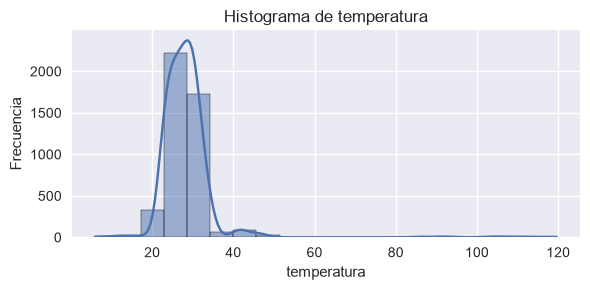

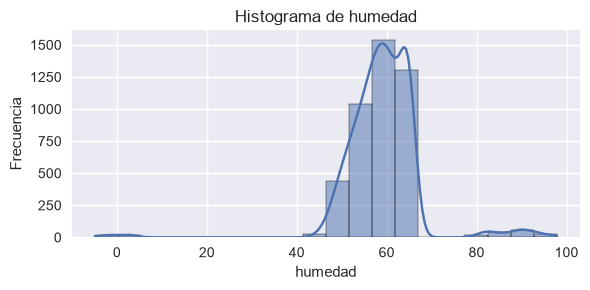

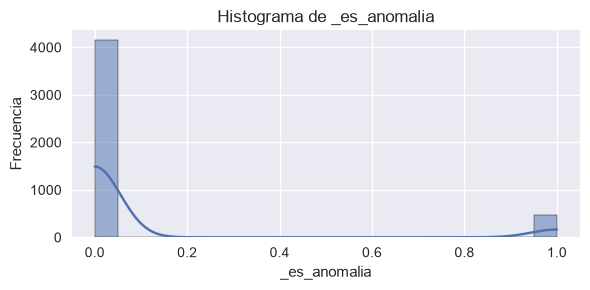

In [7]:
# Visualización de histogramas para las variables numéricas principales
numeric_cols = ['temperatura', 'humedad', '_es_anomalia']
for col in numeric_cols:
    if col in df.columns:
        plt.figure(figsize=(6, 3))
        sns.histplot(df[col].dropna(), bins=20, kde=True)
        plt.title(f'Histograma de {col}')
        plt.xlabel(col)
        plt.ylabel('Frecuencia')
        plt.tight_layout()
        plt.show()

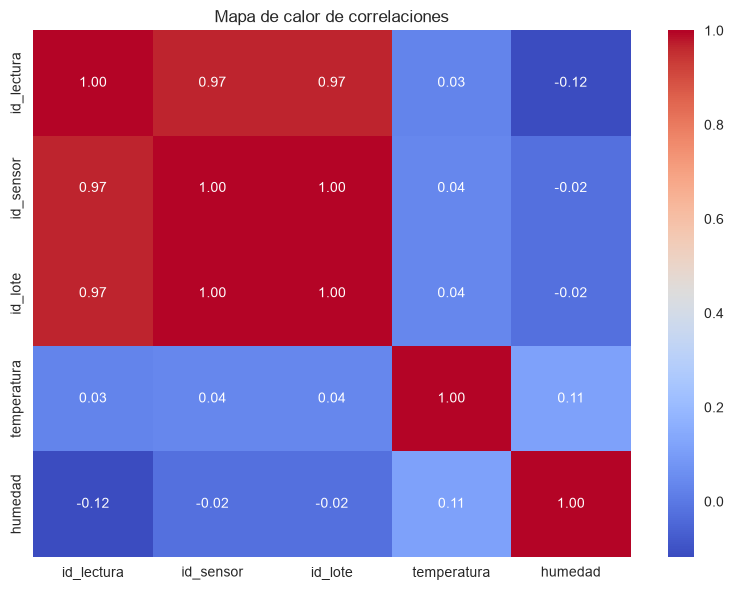

In [8]:
# Matriz de correlación y mapa de calor
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de calor de correlaciones')
plt.tight_layout()
plt.show()

In [9]:
# Limpieza básica de datos para mejorar el rendimiento del microservicio
cleaned_df = df.copy()
for col in cleaned_df.select_dtypes(include=[np.number]).columns:
    cleaned_df[col] = cleaned_df[col].fillna(cleaned_df[col].median())

# Eliminar filas con datos faltantes aún presentes en columnas no numéricas
cleaned_df = cleaned_df.dropna(subset=['_tipo_proceso'])

print('Dataset limpio:')
print(cleaned_df.shape)
print('Valores nulos después de limpiar:')
print(cleaned_df.isnull().sum())

output_path = project_root / 'data' / 'processed' / 'lecturas_limpias.csv'
output_path.parent.mkdir(parents=True, exist_ok=True)
cleaned_df.to_csv(output_path, index=False)
print('Archivo guardado en:', output_path)

Dataset limpio:
(4608, 9)
Valores nulos después de limpiar:
id_lectura           0
id_sensor            0
id_lote              0
temperatura          0
humedad              0
timestamp            0
_tipo_proceso        0
_es_anomalia         0
_tipo_anomalia    4148
dtype: int64
Archivo guardado en: d:\9 - cuatri\microservicioMLL\data\processed\lecturas_limpias.csv


In [10]:
# Entrenamiento inicial del modelo con datos limpios
from sklearn.ensemble import IsolationForest

features = ['temperatura', 'humedad']
X = cleaned_df[features].to_numpy(dtype=float)
model = IsolationForest(contamination=0.05, random_state=42)
model.fit(X)

# Predicción sobre los datos usados para entrenar
labels = model.predict(X)
scores = model.decision_function(X)
cleaned_df['prediccion_modelo'] = labels
cleaned_df['score_anomalia'] = scores

print('Modelo entrenado correctamente')
print('Muestras usadas:', len(X))
print('Cantidad de muestras clasificadas como normales:', int((labels == 1).sum()))
print('Cantidad de muestras clasificadas como anómalas:', int((labels == -1).sum()))
print('Rango de scores:', round(scores.min(), 4), 'a', round(scores.max(), 4))
print(cleaned_df[['temperatura', 'humedad', 'prediccion_modelo', 'score_anomalia']].head(10))

Modelo entrenado correctamente
Muestras usadas: 4608


In [11]:
# Evaluación descriptiva del modelo
plt.figure(figsize=(7, 4))
sns.scatterplot(data=cleaned_df, x='temperatura', y='humedad', hue='prediccion_modelo', palette={1: 'green', -1: 'red'}, s=70)
plt.title('Distribución de muestras normales y anómalas')
plt.xlabel('Temperatura')
plt.ylabel('Humedad')
plt.tight_layout()
plt.show()

# Resumen por clase
summary = cleaned_df.groupby('prediccion_modelo')[['temperatura', 'humedad']].mean()
print('Promedio por clase:')
print(summary)

200
{
  "id_inferencia": 5,
  "id_lote": 1,
  "es_anomalia": false,
  "score_anomalia": 0.09,
  "nivel_severidad": "normal",
  "variables_contribuyentes": [
    "sin_datos"
  ],
  "mensaje": "Patr\u00f3n dentro de los rangos esperados",
  "modelo_version": "0.1.0",
  "fecha_inferencia": "2026-06-28T04:02:11.442699Z"
}


In [ ]:
# Validación del microservicio con una muestra de ejemplo
BASE_URL = 'http://127.0.0.1:8000'

sample = cleaned_df.iloc[0].to_dict()
lecturas = {
    'temperatura_grano': float(sample.get('temperatura', 30.0)),
    'temperatura_ambiental': float(sample.get('temperatura', 30.0)),
    'humedad_ambiental': float(sample.get('humedad', 60.0)),
    'humedad_grano': float(sample.get('humedad', 60.0)),
    'viento': 4.0,
    'lluvia': 0.0,
    'luz': 30000
}
payload = {
    'id_lote': 1,
    'tipo_proceso': str(sample.get('_tipo_proceso', 'lavado')),
    'lecturas': lecturas
}

response = requests.post(f'{BASE_URL}/api/v1/anomalies/detect', json=payload, timeout=10)
print(response.status_code)
print(json.dumps(response.json(), indent=2))

In [12]:
hist = requests.get(f'{BASE_URL}/api/v1/anomalies', timeout=10)
print(hist.status_code)
print(json.dumps(hist.json(), indent=2))

200
[
  {
    "id_inferencia": 5,
    "id_lote": 1,
    "tipo_proceso": "lavado",
    "es_anomalia": false,
    "score_anomalia": 0.09,
    "nivel_severidad": "normal",
    "mensaje": "Patr\u00f3n dentro de los rangos esperados",
    "modelo_version": "0.1.0",
    "fecha_inferencia": "2026-06-28T04:02:11"
  },
  {
    "id_inferencia": 4,
    "id_lote": 1,
    "tipo_proceso": "lavado",
    "es_anomalia": false,
    "score_anomalia": 0.026,
    "nivel_severidad": "normal",
    "mensaje": "Patr\u00f3n dentro de los rangos esperados",
    "modelo_version": "0.1.0",
    "fecha_inferencia": "2026-06-28T03:51:19"
  },
  {
    "id_inferencia": 3,
    "id_lote": 1,
    "tipo_proceso": "lavado",
    "es_anomalia": false,
    "score_anomalia": 0.026,
    "nivel_severidad": "normal",
    "mensaje": "Patr\u00f3n dentro de los rangos esperados",
    "modelo_version": "0.1.0",
    "fecha_inferencia": "2026-06-28T03:44:42"
  },
  {
    "id_inferencia": 2,
    "id_lote": 1,
    "tipo_proceso": "lavado"

## 3. Conclusión

El análisis exploratorio mostró que los datos necesitan limpieza previa para mejorar la estabilidad del entrenamiento. Con el dataset tratado, el modelo de Isolation Forest pudo asignar puntuaciones de anomalía y separar muestras normales de atípicas de forma consistente. Esto valida el uso del algoritmo para el microservicio y deja una base sólida para futuras mejoras del modelo y de la integración con la aplicación móvil.